# CanSat – Analisi dati
Dataset: GRASP (temperatura, pressione, quota, PM) e VAMOS (CO₂, vento)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

DATA = Path('CanSat data utili')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1 · GRASP – sensori primari

In [2]:
# Il CSV ha una colonna vuota in posizione 1, la saltiamo
grasp = pd.read_csv(
    DATA / 'science_GRASP.csv',
    header=0,
    usecols=[0, 2, 3, 4, 5, 6],
    names=['t_ms', 'temp_C', 'press_Pa', 'alt_m', 'pm25', 'pm10'],
    skipfooter=8,   # rimuove la sezione FLIGHT EVENT TIMELINE
    engine='python'
)
grasp = grasp.dropna().astype(float)
grasp['t_s'] = grasp['t_ms'] / 1000

# Evento: freefall a 2521545 ms, touchdown a 2697971 ms
T_FREEFALL = 2521.545   # s
T_TOUCH    = 2697.971   # s

print(grasp.describe().round(2))

             t_ms   temp_C  press_Pa    alt_m     pm25     pm10      t_s
count     1716.00  1716.00   1716.00  1716.00  1716.00  1716.00  1716.00
mean   2557809.44    14.75  87034.26  1263.84    14.82    18.60  2557.81
std      30448.48     0.23    162.52     7.86     2.56     3.39    30.45
min    2521583.00    14.49  81261.94  1226.93     3.00     3.00  2521.58
25%    2532819.50    14.74  86954.22  1258.36    14.00    18.00  2532.82
50%    2552649.00    14.76  87038.89  1263.70    15.00    19.00  2552.65
75%    2572475.50    14.77  87095.90  1271.69    16.00    20.00  2572.48
max    2697971.00    24.05  87430.34  1273.81    21.00    28.00  2697.97


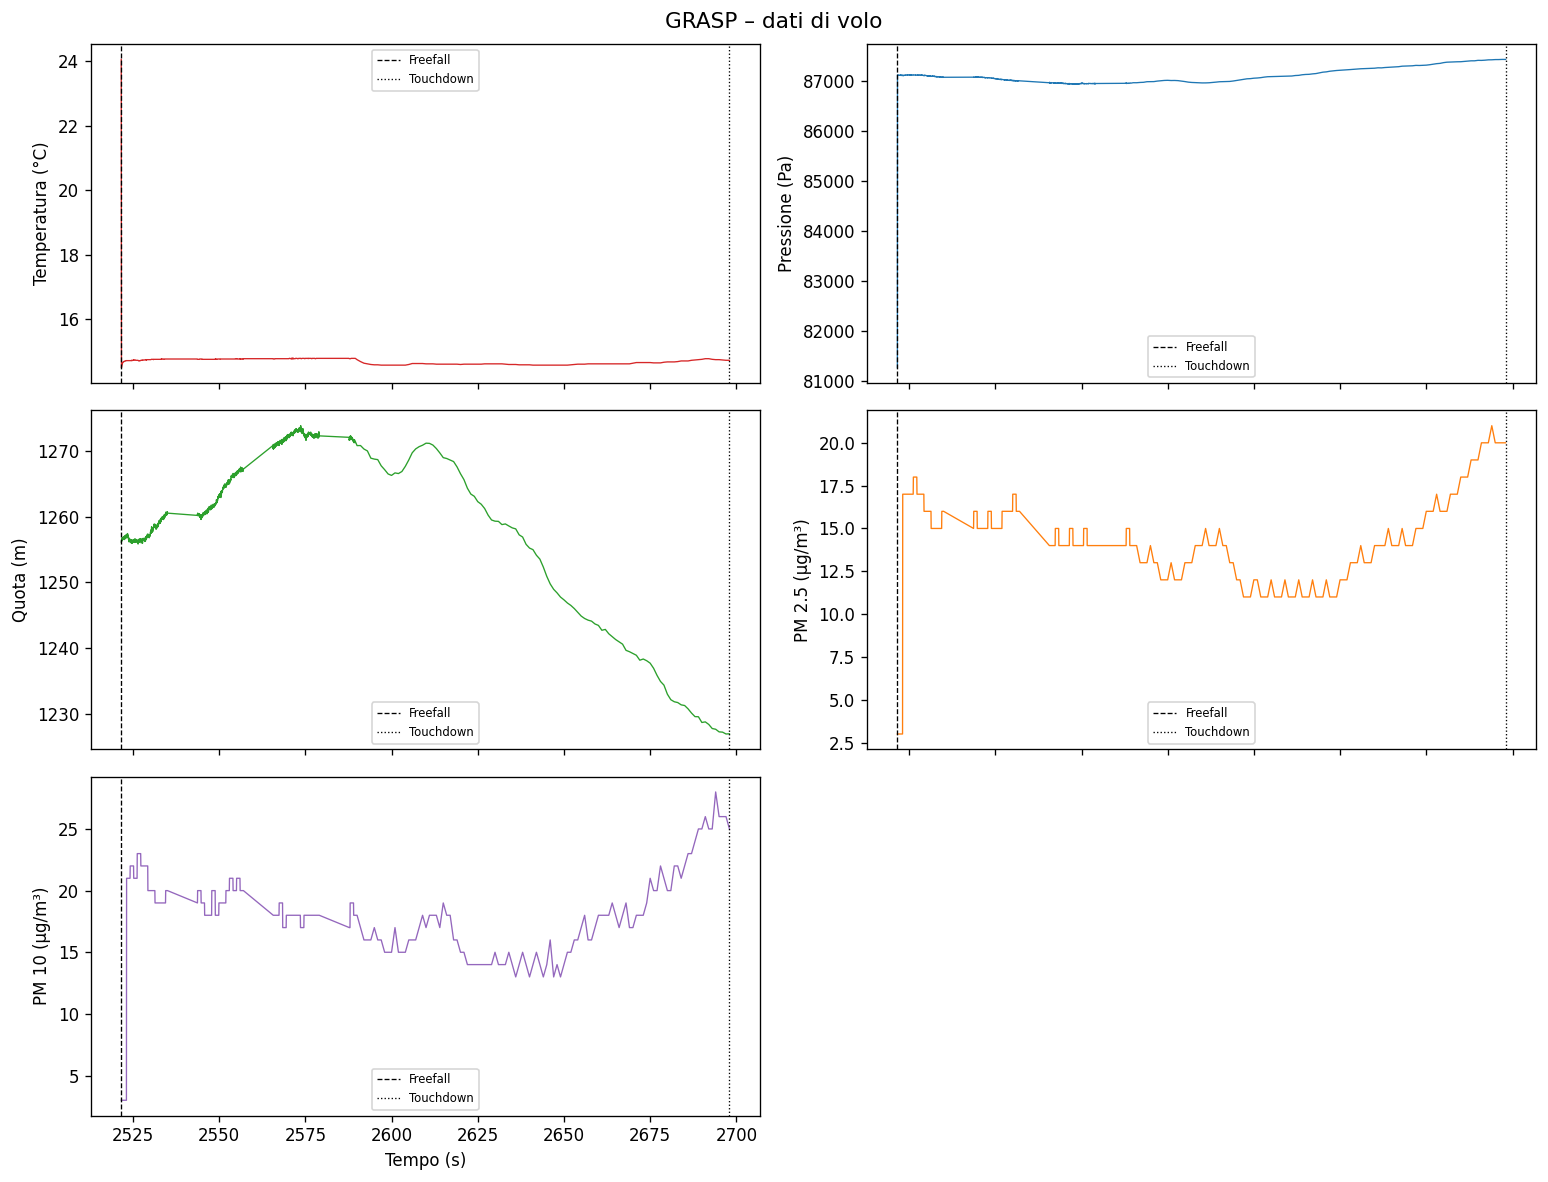

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=True)
fig.suptitle('GRASP – dati di volo', fontsize=13)

pairs = [
    ('temp_C',  'Temperatura (°C)',          'tab:red'),
    ('press_Pa','Pressione (Pa)',             'tab:blue'),
    ('alt_m',   'Quota (m)',                  'tab:green'),
    ('pm25',    'PM 2.5 (µg/m³)',             'tab:orange'),
    ('pm10',    'PM 10 (µg/m³)',              'tab:purple'),
]

for ax, (col, label, color) in zip(axes.flat, pairs):
    ax.plot(grasp['t_s'], grasp[col], color=color, lw=0.8)
    ax.axvline(T_FREEFALL, color='k', ls='--', lw=0.8, label='Freefall')
    ax.axvline(T_TOUCH,    color='k', ls=':',  lw=0.8, label='Touchdown')
    ax.set_ylabel(label)
    ax.legend(fontsize=7)

axes[-1, -1].set_visible(False)   # cella vuota
for ax in axes[-1, :]:
    ax.set_xlabel('Tempo (s)')

plt.tight_layout()
plt.savefig('grasp_overview.png')
plt.show()

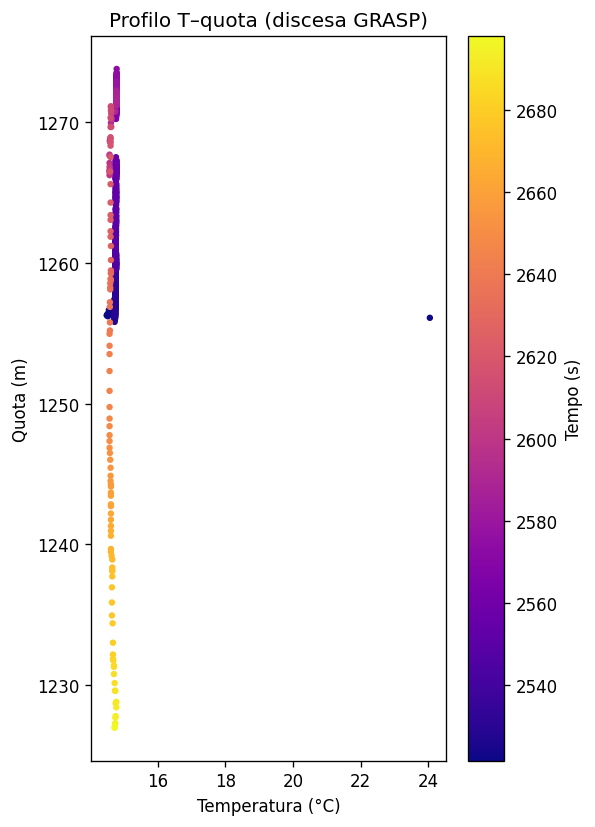

In [4]:
# Profilo quota-temperatura (solo fase di discesa)
descent = grasp[(grasp['t_s'] >= T_FREEFALL) & (grasp['t_s'] <= T_TOUCH)].copy()

fig, ax = plt.subplots(figsize=(5, 7))
sc = ax.scatter(descent['temp_C'], descent['alt_m'],
                c=descent['t_s'], cmap='plasma', s=8)
plt.colorbar(sc, ax=ax, label='Tempo (s)')
ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Quota (m)')
ax.set_title('Profilo T–quota (discesa GRASP)')
plt.tight_layout()
plt.savefig('grasp_profilo_T_quota.png')
plt.show()

## 2 · VAMOS – CO₂, temperatura, pressione

In [5]:
vamos = pd.read_csv(DATA / 'science_VAMOS.csv')
vamos.columns = ['t_ms', 'co2_ppm', 'temp_C', 'press_hPa']
vamos = vamos[vamos['t_ms'] != 'timestamp_ms'].copy()
vamos = vamos.apply(pd.to_numeric, errors='coerce').dropna()
vamos['t_s'] = vamos['t_ms'] / 1000

# Il sensore CO₂ è a 0 durante il warm-up; filtriamo quei campioni
vamos_co2 = vamos[vamos['co2_ppm'] > 0].copy()

print(vamos.describe().round(2))

             t_ms  co2_ppm   temp_C  press_hPa      t_s
count     9349.00  9349.00  9349.00    9349.00  9349.00
mean   2070123.39   586.74    17.07     934.81  2070.12
std    1914038.30   161.14     3.72      24.68  1914.04
min       8070.00     0.00    10.91     868.03     8.07
25%     360761.00   468.00    14.01     941.62   360.76
50%    1309074.00   562.00    15.44     941.99  1309.07
75%    3700479.00   652.00    21.13     949.61  3700.48
max    6087490.00  1287.00    23.31     949.94  6087.49


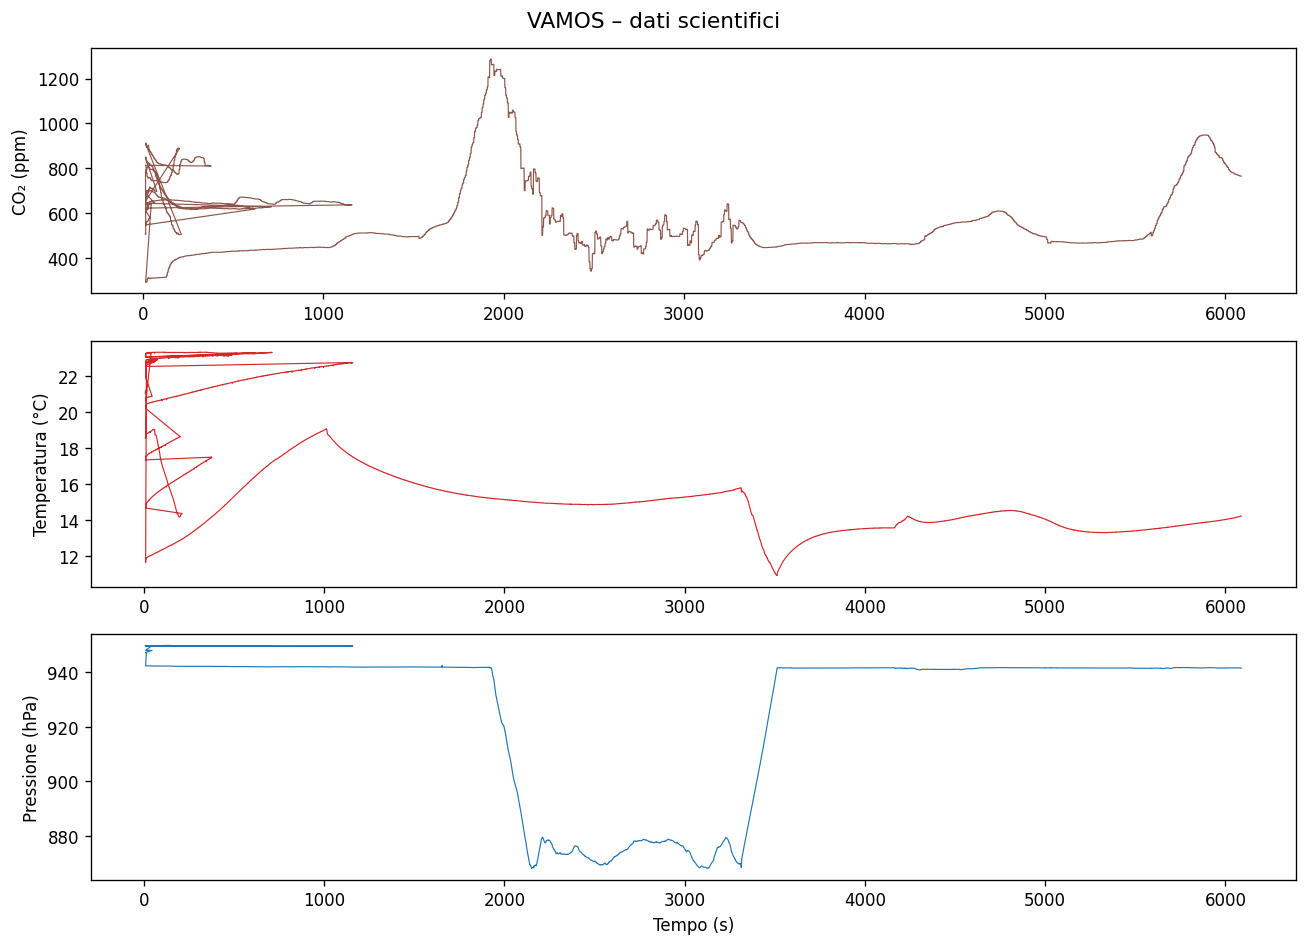

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=False)
fig.suptitle('VAMOS – dati scientifici', fontsize=13)

axes[0].plot(vamos_co2['t_s'], vamos_co2['co2_ppm'], color='tab:brown', lw=0.7)
axes[0].set_ylabel('CO₂ (ppm)')

axes[1].plot(vamos['t_s'], vamos['temp_C'], color='tab:red', lw=0.7)
axes[1].set_ylabel('Temperatura (°C)')

axes[2].plot(vamos['t_s'], vamos['press_hPa'], color='tab:blue', lw=0.7)
axes[2].set_ylabel('Pressione (hPa)')
axes[2].set_xlabel('Tempo (s)')

plt.tight_layout()
plt.savefig('vamos_science.png')
plt.show()

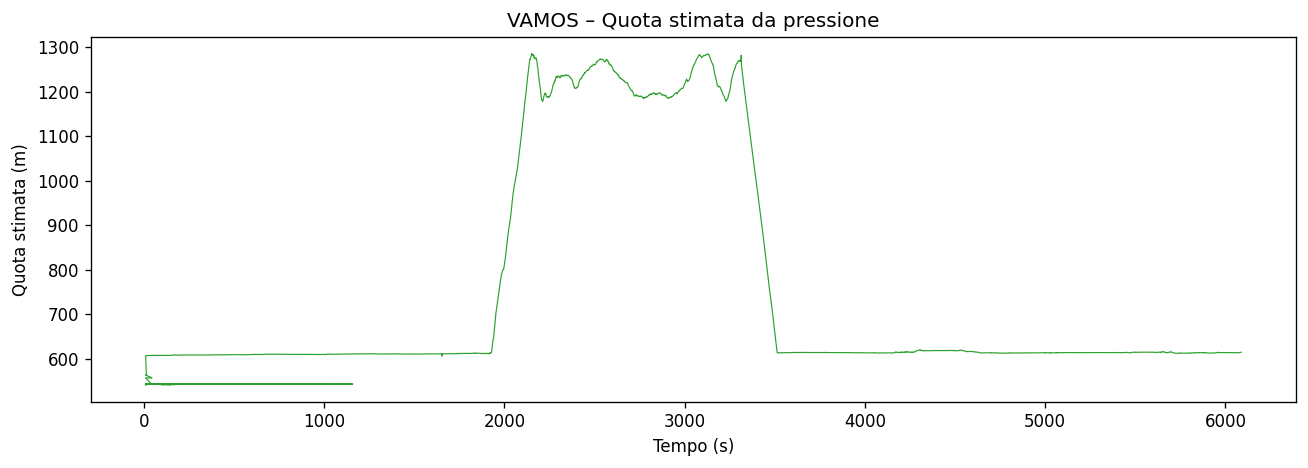

In [7]:
# Quota stimata da pressione VAMOS (formula barometrica, riferimento 1013.25 hPa)
P0 = 1013.25
vamos['alt_est_m'] = 44330 * (1 - (vamos['press_hPa'] / P0) ** (1 / 5.255))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(vamos['t_s'], vamos['alt_est_m'], color='tab:green', lw=0.7)
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Quota stimata (m)')
ax.set_title('VAMOS – Quota stimata da pressione')
plt.tight_layout()
plt.savefig('vamos_quota.png')
plt.show()

## 3 · VAMOS – Vento

In [8]:
wind = pd.read_csv(DATA / 'wind_VAMOS.csv')
wind = wind[wind['timestamp_ms'] != 'timestamp_ms'].copy()
wind = wind.apply(pd.to_numeric, errors='coerce').dropna()
wind['t_s'] = wind['timestamp_ms'] / 1000

print(wind.describe().round(3))

       timestamp_ms  wind_acceleration  wind_acceleration_direction  \
count      9280.000           9280.000                     9280.000   
mean    2079949.532              1.219                      162.914   
std     1913137.975              2.307                       54.649   
min        8642.000              0.000                        0.000   
25%      365583.500              0.287                      134.690   
50%     1339320.500              0.311                      155.040   
75%     3713052.750              0.467                      178.047   
max     6082379.000             12.176                      359.750   

       wind_speed  x_wind_acc  y_wind_acc  x_wind_mps  y_wind_mps  tumbling  \
count    9280.000    9280.000    9280.000    9280.000    9280.000    9280.0   
mean        0.707       0.400      -0.733       0.230      -0.424       0.0   
std         1.336       1.726       1.771       1.000       1.025       0.0   
min         0.000      -9.217     -11.737   

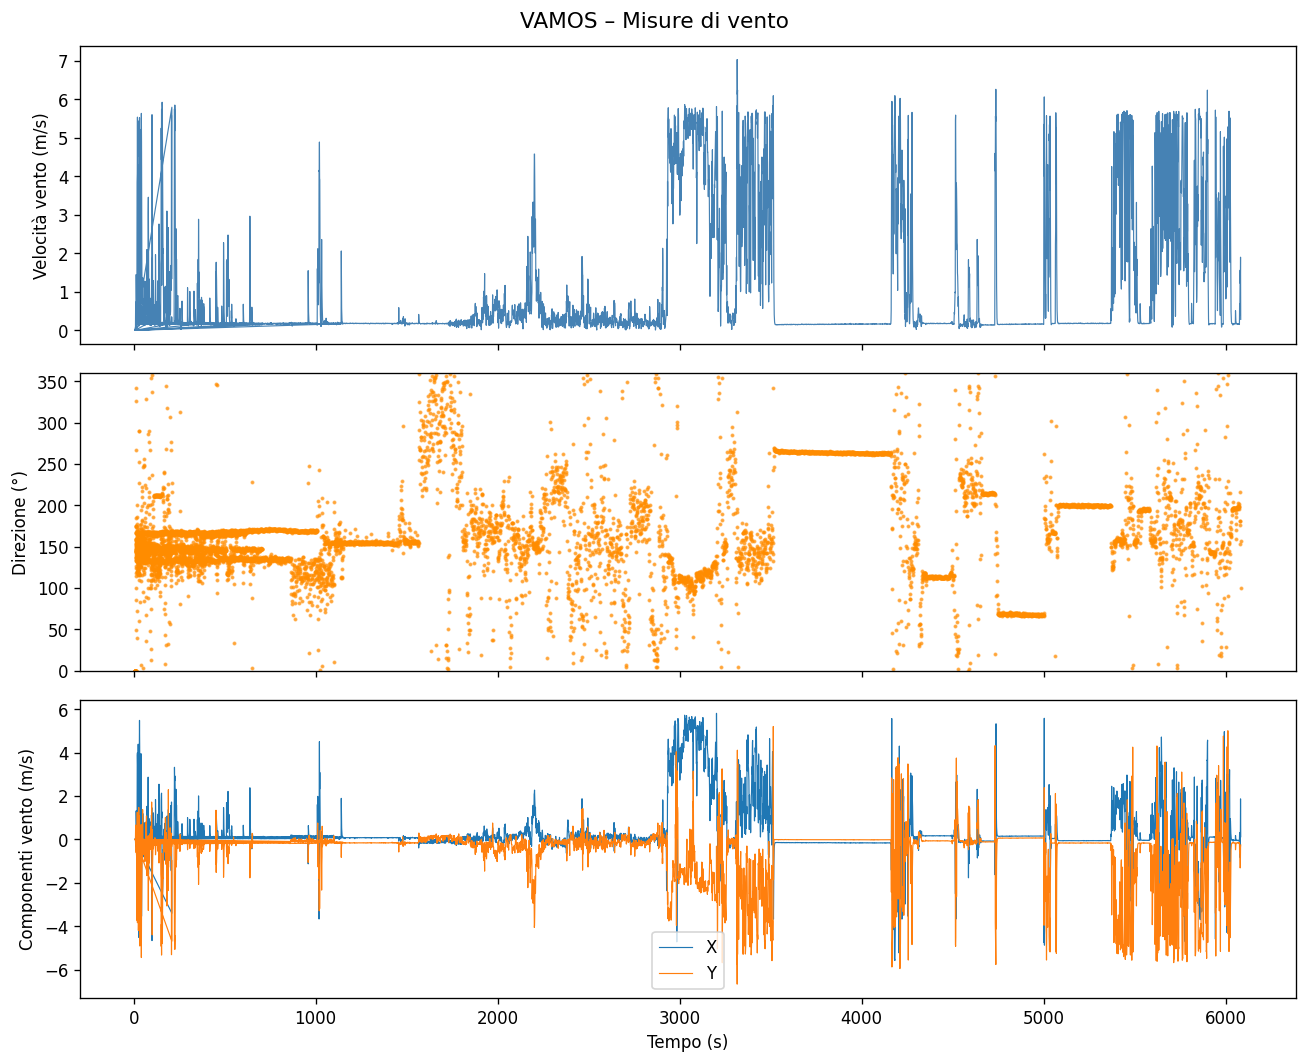

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
fig.suptitle('VAMOS – Misure di vento', fontsize=13)

axes[0].plot(wind['t_s'], wind['wind_speed'], color='steelblue', lw=0.7)
axes[0].set_ylabel('Velocità vento (m/s)')

axes[1].scatter(wind['t_s'], wind['wind_acceleration_direction'],
                s=2, c='darkorange', alpha=0.6)
axes[1].set_ylabel('Direzione (°)')
axes[1].set_ylim(0, 360)

axes[2].plot(wind['t_s'], wind['x_wind_mps'], label='X', lw=0.7)
axes[2].plot(wind['t_s'], wind['y_wind_mps'], label='Y', lw=0.7)
axes[2].set_ylabel('Componenti vento (m/s)')
axes[2].set_xlabel('Tempo (s)')
axes[2].legend()

plt.tight_layout()
plt.savefig('vamos_wind.png')
plt.show()

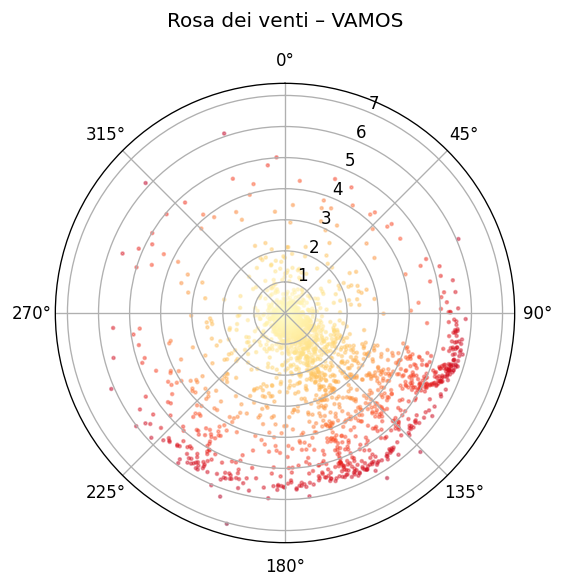

In [10]:
# Rosa dei venti
theta = np.deg2rad(wind['wind_acceleration_direction'])
r     = wind['wind_speed']

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(5, 5))
ax.scatter(theta, r, s=3, alpha=0.4, c=r, cmap='YlOrRd')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_title('Rosa dei venti – VAMOS', pad=15)
plt.tight_layout()
plt.savefig('vamos_wind_rose.png')
plt.show()

Campioni con tumbling: 0.0%


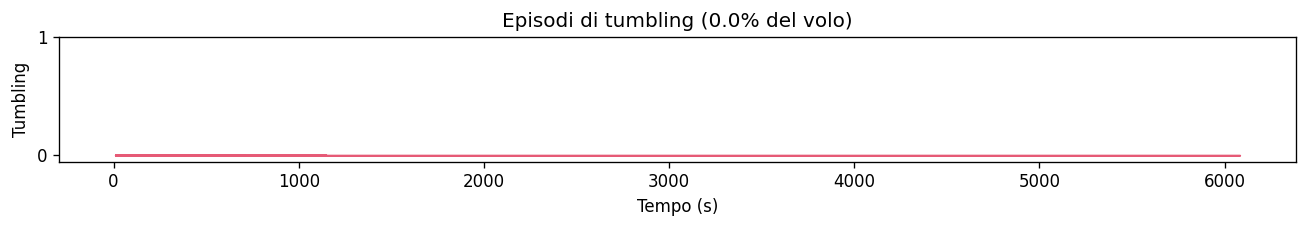

In [11]:
# Episodi di tumbling
tumbling_frac = wind['tumbling'].mean() * 100
print(f'Campioni con tumbling: {tumbling_frac:.1f}%')

fig, ax = plt.subplots(figsize=(11, 2))
ax.fill_between(wind['t_s'], wind['tumbling'], step='mid',
                color='crimson', alpha=0.7)
ax.set_ylabel('Tumbling')
ax.set_xlabel('Tempo (s)')
ax.set_yticks([0, 1])
ax.set_title(f'Episodi di tumbling ({tumbling_frac:.1f}% del volo)')
plt.tight_layout()
plt.savefig('vamos_tumbling.png')
plt.show()

## 4 · Statistiche riassuntive

In [12]:
print('=== GRASP ===')
print(f"Temperatura:  min={grasp['temp_C'].min():.2f}°C  max={grasp['temp_C'].max():.2f}°C  media={grasp['temp_C'].mean():.2f}°C")
print(f"Quota:        min={grasp['alt_m'].min():.0f} m   max={grasp['alt_m'].max():.0f} m")
print(f"PM2.5:        media={grasp['pm25'].mean():.1f} µg/m³  max={grasp['pm25'].max():.1f} µg/m³")
print(f"PM10:         media={grasp['pm10'].mean():.1f} µg/m³  max={grasp['pm10'].max():.1f} µg/m³")

print('\n=== VAMOS Science ===')
print(f"CO₂ (post-warmup): min={vamos_co2['co2_ppm'].min():.0f} ppm  max={vamos_co2['co2_ppm'].max():.0f} ppm  media={vamos_co2['co2_ppm'].mean():.0f} ppm")
print(f"Temperatura:       min={vamos['temp_C'].min():.2f}°C  max={vamos['temp_C'].max():.2f}°C")
print(f"Pressione:         min={vamos['press_hPa'].min():.2f} hPa  max={vamos['press_hPa'].max():.2f} hPa")

print('\n=== VAMOS Wind ===')
print(f"Velocità vento: media={wind['wind_speed'].mean():.3f} m/s  max={wind['wind_speed'].max():.3f} m/s")
print(f"Tumbling:       {tumbling_frac:.1f}% dei campioni")

=== GRASP ===
Temperatura:  min=14.49°C  max=24.05°C  media=14.75°C
Quota:        min=1227 m   max=1274 m
PM2.5:        media=14.8 µg/m³  max=21.0 µg/m³
PM10:         media=18.6 µg/m³  max=28.0 µg/m³

=== VAMOS Science ===
CO₂ (post-warmup): min=291 ppm  max=1287 ppm  media=591 ppm
Temperatura:       min=10.91°C  max=23.31°C
Pressione:         min=868.03 hPa  max=949.94 hPa

=== VAMOS Wind ===
Velocità vento: media=0.707 m/s  max=7.038 m/s
Tumbling:       0.0% dei campioni
